In [44]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np
import h5py as h5
import pandas as pd
from astropy.cosmology import FlatLambdaCDM, z_at_value
from scipy.stats import spearmanr
import eagle_tools
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.interpolate import interp1d
from scipy.optimize import brentq
import os
print(os.getcwd())
import sys
sys.path.insert(0, '.')  # current folder first

notebook_dir = '/users/arirrobe/MachineLearning/MBH-GalaxyHalo-SHAP/scripts'
if notebook_dir not in sys.path:
    sys.path.insert(0, notebook_dir)

import shap
import windowshap

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import minmax_scale, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from scipy.stats import spearmanr, binned_statistic
import time
import timeit
from bayes_opt import BayesianOptimization
from sklearn.model_selection import cross_val_score
import seaborn as sns

import optuna
import xgboost as xgb

# Use custom matplotlib template
plt.style.use('/users/arirrobe/MachineLearning/MBH-EBind-MorphoKinem/mnras_mpl.stylesheet')

cosmology = FlatLambdaCDM(H0=67.74, Om0=0.3089)

omega_b = 0.0482519
omega_0 = 0.307
omega_lambda = 0.693
Z_solar = 0.012663729
M_solar = 1.98841e33
eps_r = 0.1
eps_f = 0.15
c = 2.99792458e10
yr = 3.154e7
H_0 = 67.77
H_0_cgs = 3.2407789e-18
Mpc = 3.086e24 
kpc = 3.086e21
pc = 3.086e18
G = 6.67e-8
km = 1e5
h = 0.6777
boxsize = 67770/h
Z_w = 0.002
gamma_wz = 2
f_wz = 0.25
ebar_w = 3.6
N_SNII = 0.0118
rho_crit =  8.6e-30 #g/cm^3 given by 3H^2/8piG

cgs_conv_mass = 1.989e+43
cgs_conv_sfr = 6.304278922345484e+25
cgs_conv_birthdensity = 6.769911178294543e-31
cgs_conv_acc_rate = 6.445909132449984e+23
cgs_conv_vel = 100000
cgs_conv_radius = 3.085678e+21

dm_particlemass = 9.7e6*M_solar

load_path = '/users/arirrobe/MachineLearning/EAGLE_Datasets'
archive_load_path = '/mnt/scratch/users/arijdavi/hpcdata0_backup/EAGLE_catalogues/L0100N1504/REFERENCE/028_z000p000'
save_path = '/users/arirrobe/MachineLearning/MBH-GalaxyHalo-SHAP/outputs/'

/users/arirrobe/MachineLearning/MBH-GalaxyHalo-SHAP/scripts


In [71]:
with h5.File(f'{load_path}/L0100N1504_AllHaloProperties.h5', 'r') as fi:
    matched_group_nums = fi['/GroupNumber'][()].astype(np.int32)
    kappa_co = fi['kappa_co'][()]
    e_agn = fi['E_AGN'][()]
    e_bind = fi['E_Bind'][()]
    assembly_time = fi['AssemblyTime'][()]
    conc = fi['Vmax_V200'][()]
    m200 = fi['M200'][()]
fi.close()

with h5.File(f'{load_path}/L0100N1504_NewFeedback.h5', 'r') as fi:
    group_nums = fi['/GroupNumber'][()].astype(np.int64)
    m_bh = fi['/M_BH_INTERP/'][()][:,0]
fi.close()

with h5.File(f'{load_path}/L0100N1504_MorphoKinem.h5', 'r') as fi:
    all_morpho_kinem = fi['AllMorphoKinem'][()]
    all_morpho_z = fi['AllMorphoKinem'][()][:,1]
    all_ellipticity = fi['AllMorphoKinem'][()][:,3]
    all_triaxiality = fi['AllMorphoKinem'][()][:,4]
fi.close()

with h5.File(f'{load_path}/L0100N1504_All_DiscToTotal.h5', 'r') as fi:
    all_disc_to_total = fi['All_DiscToTotal'][()]
fi.close()

with h5.File(f'{load_path}/L0100N1504_kappa_gas.h5', 'r') as fi:
    all_kappa_gas = fi['kappa_gas'][()]
fi.close()

all_kappa = np.array(pd.read_csv(f'{load_path}/AllKappaInfo.csv', index_col=0, skiprows=0))

missing_idx = []
for i, gn in enumerate(matched_group_nums):
    if gn == 1:
        all_z = all_kappa[all_kappa[:,0] == gn, 1]
    
    galaxy = all_kappa[all_kappa[:,0] == gn]
    if galaxy.shape[0] <= 8:
        missing_idx.append(gn)

missing_idx = np.unique(missing_idx)
print(missing_idx)
print(len(missing_idx))

all_kappa = np.delete(all_kappa, np.argwhere(np.isin(all_kappa[:,0], missing_idx)), 0)
all_kappa_gas = np.delete(all_kappa_gas, np.argwhere(np.isin(all_kappa_gas[:,0], missing_idx)), 0)
all_triaxiality = np.delete(all_triaxiality, np.argwhere(np.isin(all_morpho_kinem[:,0], missing_idx)), 0)
all_ellipticity = np.delete(all_ellipticity, np.argwhere(np.isin(all_morpho_kinem[:,0], missing_idx)), 0)
all_morpho_z = np.delete(all_morpho_z, np.argwhere(np.isin(all_morpho_kinem[:,0], missing_idx)), 0)
all_morpho_kinem = np.delete(all_morpho_kinem, np.argwhere(np.isin(all_morpho_kinem[:,0], missing_idx)), 0)
all_disc_to_total = np.delete(all_disc_to_total, np.argwhere(np.isin(all_disc_to_total[:,0], missing_idx)), 0)

all_kappa_gas[:,2][np.where(np.isnan(all_kappa_gas[:,2]))] = np.min(all_kappa_gas[:,2][np.where(~np.isnan(all_kappa_gas[:,2]))])
all_kappa_gas[:,2][np.where(all_kappa_gas[:,2] == -10)] = np.min(all_kappa_gas[:,2][np.where(all_kappa_gas[:,2] != -10)])
    
kappa_co = all_kappa[all_kappa[:,1]<= 0.001, 2]
kappa_gas = all_kappa_gas[all_kappa_gas[:,1]<= 0.001, 2]
triax_z0 = all_triaxiality[all_morpho_z <= 0.001]
ellip_z0 = all_ellipticity[all_morpho_z <= 0.001]
disc_to_total = all_disc_to_total[all_disc_to_total[:,1] <= 0.001, 2]

all_alpha_m = all_morpho_kinem.copy()[:,:2]
new_col = ((all_ellipticity**2) + 1 - all_triaxiality)/2
all_alpha_m = np.concatenate([all_alpha_m, new_col[:, None]], axis=1)
alpha_m = all_alpha_m[all_alpha_m[:,1] <= 0.001, 2]

idx_in_group_nums = np.array([np.where(group_nums == gn)[0][0] for gn in matched_group_nums])
m_bh = m_bh[idx_in_group_nums]


with h5.File(f'{archive_load_path}/DMO_binding_energies.hdf5', 'r') as fi:
    e_bind_2500 = fi['Particle_E_2500'][()]
    e_bind_gn = fi['GroupNumber'][()]
fi.close()


idx_in_ebind_gn = np.array([np.where(e_bind_gn == gn)[0][0] for gn in matched_group_nums])
e_bind_2500 = e_bind_2500[idx_in_ebind_gn]

with h5.File(f'{load_path}/L0100N1504_Mstar_MBH_Histories.h5', 'r') as fi:
    all_mstar_mbh = fi['Mstar_MBH_Arr'][()]
fi.close()

all_mstar_mbh = np.delete(all_mstar_mbh, np.argwhere(all_mstar_mbh[:,0]==0), 0)
all_mstar_mbh = all_mstar_mbh[np.lexsort((all_mstar_mbh[:,1], all_mstar_mbh[:,0]))]


all_mstar = np.delete(all_mstar_mbh, 2, 1)
all_mbh = all_mstar_mbh[:,:3]
all_mbh[all_mbh[:,1]<= 0.001, 2] = m_bh

all_mstar = np.delete(all_mstar, np.argwhere(np.isin(all_mstar[:,0], missing_idx)), 0)
all_mbh = np.delete(all_mbh, np.argwhere(np.isin(all_mbh[:,0], missing_idx)), 0)

m_star = all_mstar[all_mstar[:,1]<= 0.001, 2]
m_bh = all_mbh[all_mbh[:,1]<= 0.001, 2]

with h5.File(f'{load_path}/L0100N1504_M200_Histories.h5', 'r') as fi:
    all_m200 = fi['M200_Histories'][()]
fi.close()

all_m200[all_m200[:,1]<= 0.001, 2] = m200
all_m200 = np.delete(all_m200, np.argwhere(np.isin(all_m200[:,0], missing_idx)), 0)
# all_m200 = all_m200[np.argwhere((np.isin(all_mbh[:,0], all_m200[:,0])) & (np.isin(all_mbh[:,1], all_m200[:,1]))).ravel()]

pairs_mbh = np.core.records.fromarrays(
    [all_mbh[:,0], all_mbh[:,1]],
    names='group,z'
)

pairs_m200 = np.core.records.fromarrays(
    [all_m200[:,0], all_m200[:,1]],
    names='group,z'
)

mask = np.isin(pairs_m200, pairs_mbh)
all_m200 = all_m200[mask]


with h5.File(f'{load_path}/L0100N1504_30kpcApertureMaxMassAllMergers.h5', 'r') as fi:
    all_mergers = fi['AllMergerEvents'][()]  # (gn, z, major_mergers, minor_mergers, Mstar_Acc, f_exsitu)
fi.close()
all_mergers = np.delete(all_mergers, np.argwhere(np.isin(all_mergers[:,0], missing_idx)), 0)


m200 = np.log10(m200)
all_mstar[:,2] = np.log10(all_mstar[:,2])
all_mbh[:,2] = np.log10(all_mbh[:,2])
all_m200[:,2] = np.log10(all_m200[:,2])
m_star = np.log10(m_star)
m_bh = np.log10(m_bh)
e_agn = np.log10(e_agn)
e_bind = np.log10(np.abs(e_bind))
e_bind_2500 = np.log10(np.abs(e_bind_2500) * cgs_conv_mass*cgs_conv_vel / h)

missing_idx = np.argwhere(np.isin(matched_group_nums, missing_idx)).ravel()
matched_group_nums = np.delete(matched_group_nums, missing_idx)
assembly_time = np.delete(assembly_time, missing_idx)
m200 = np.delete(m200, missing_idx)
e_agn = np.delete(e_agn, missing_idx)
e_bind = np.delete(e_bind, missing_idx)
e_bind_2500 = np.delete(e_bind_2500, missing_idx)
e_bind = e_bind_2500

e_bind_sorted = e_bind[np.argsort(e_bind)]
m_star_ebind = m_star[np.argsort(e_bind)]
matched_group_nums_ebind = matched_group_nums[np.argsort(e_bind)]
m200_ebind = m200[np.argsort(e_bind)]
m_bh_ebind = m_bh[np.argsort(e_bind)]
kappa_co_ebind = kappa_co[np.argsort(e_bind)]
kappa_gas_ebind = kappa_gas[np.argsort(e_bind)]
alpha_m_ebind = alpha_m[np.argsort(e_bind)]
disc_to_total_ebind = disc_to_total[np.argsort(e_bind)]

all_redshifts = all_kappa[all_kappa[:,0]==matched_group_nums[0],1][::-1]
t_cosmic = cosmology.age(all_redshifts).value
print(all_redshifts)
print(t_cosmic)

n_samples = len(matched_group_nums)
n_features = 5

# Initialize X with -10 to mark "missing"
X = np.full((n_samples, n_features), -10.0, dtype=np.float32)

X[:,0] = kappa_co
X[:,1] = kappa_gas
X[:,2] = alpha_m
X[:,3] = disc_to_total
X[:,4] = all_mergers[np.isclose(all_mergers[:,1], all_redshifts[-1]), 5] # f_exsitu

# Create a mapping from galaxy ID -> row index
group_to_idx = {g: i for i, g in enumerate(matched_group_nums)}

print("X shape:", X.shape)


ebind_range = (e_bind >= 58) & (e_bind <= 58.5)
low_kappa = np.percentile(kappa_co[ebind_range], 25)
high_kappa = np.percentile(kappa_co[ebind_range], 75)

low_kappa_ids = matched_group_nums[ebind_range][kappa_co[ebind_range] <= low_kappa]
high_kappa_ids = matched_group_nums[ebind_range][kappa_co[ebind_range] >= high_kappa]
test_kappa_ids = matched_group_nums[ebind_range][(kappa_co[ebind_range] <= low_kappa) | (kappa_co[ebind_range] >= high_kappa)]

gal_mask_train = ~np.isin(matched_group_nums, test_kappa_ids)
gal_mask_test  = np.isin(matched_group_nums, test_kappa_ids)

# X_train = X[gal_mask_train, :, :]
# X_test  = X[gal_mask_test, :, :]

# y_train = m_bh[gal_mask_train]
# y_test  = m_bh[gal_mask_test]

# Train-test split
y = m_bh

indices = np.arange(X.shape[0])
X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(X, y, indices, test_size=0.2, shuffle=True, random_state=42)
e_bind_train, e_bind_test = e_bind[indices_train], e_bind[indices_test]
X_train, X_val, y_train, y_val, indices_train, indices_val = train_test_split(X_train, y_train, indices_train, test_size=0.1, shuffle=True, random_state=42)
e_bind_train, e_bind_val = e_bind[indices_train], e_bind[indices_val]

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

# Copy arrays to avoid overwriting
X_train_scaled = X_train.copy()
X_val_scaled  = X_val.copy()
X_test_scaled  = X_test.copy()

# Scale per feature across all galaxies and timesteps
N, F = X_train.shape
scaler = MinMaxScaler(feature_range=(0, 1))

for f in range(F):
    # Flatten the feature across all samples and timesteps
    feature_train = X_train[:, f].flatten()
    valid_mask = feature_train > -10

    # Only fit/transform valid values
    feature_train_scaled = np.zeros_like(feature_train)
    feature_train_scaled[valid_mask] = scaler.fit_transform(feature_train[valid_mask].reshape(-1, 1)).flatten()
    feature_train_scaled[~valid_mask] = -10  # keep missing values as -10

    # Put it back
    X_train_scaled[:,f] = feature_train_scaled.reshape(N)

    # Apply same scaler to validation
    feature_val = X_val[:,f].flatten()
    valid_mask_val = feature_val > -10
    feature_val_scaled = np.zeros_like(feature_val)
    feature_val_scaled[valid_mask_val] = scaler.transform(feature_val[valid_mask_val].reshape(-1, 1)).flatten()
    feature_val_scaled[~valid_mask_val] = -10
    X_val_scaled[:,f] = feature_val_scaled.reshape(X_val.shape[0])
    
    # Apply same scaler to test
    feature_test = X_test[:,f].flatten()
    valid_mask_test = feature_test > -10
    feature_test_scaled = np.zeros_like(feature_test)
    feature_test_scaled[valid_mask_test] = scaler.transform(feature_test[valid_mask_test].reshape(-1, 1)).flatten()
    feature_test_scaled[~valid_mask_test] = -10
    X_test_scaled[:,f] = feature_test_scaled.reshape(X_test.shape[0])

[ 643  741  799  970 1039 1280 1447 1760 1772 1851 2064 2080 2323 2521
 2566 2649 2656 2682 2780 2811 2854 2925 3016 3022 3143 3274 3356 3387
 3424 3469 3547 3615 3643 3702 3777 3952]
36
[4.4852138e+00 3.9836636e+00 3.5279765e+00 3.0165045e+00 2.4784133e+00
 2.2370370e+00 2.0124102e+00 1.7369658e+00 1.4867073e+00 1.2593315e+00
 1.0041217e+00 8.6505055e-01 7.3562960e-01 6.1518980e-01 5.0310730e-01
 3.6566857e-01 2.7090108e-01 1.8270987e-01 1.0063854e-01 2.2204460e-16]
[ 1.34472796  1.551595    1.78984634  2.13875274  2.64578454  2.94114736
  3.26795588  3.75748139  4.31472894  4.9464489   5.85033684  6.45755519
  7.11544418  7.82491315  8.58613433  9.68036537 10.55842338 11.48297519
 12.4509065  13.80271833]
X shape: (3374, 5)
(2429, 5) (270, 5) (675, 5)
(2429,) (270,) (675,)


[0]	validation_0-rmse:0.68124	validation_1-rmse:0.69849
[10]	validation_0-rmse:0.44531	validation_1-rmse:0.58791
[20]	validation_0-rmse:0.38311	validation_1-rmse:0.58965


MSE: 0.337
RMSE: 0.580
MAE: 0.477
R^2: 0.543




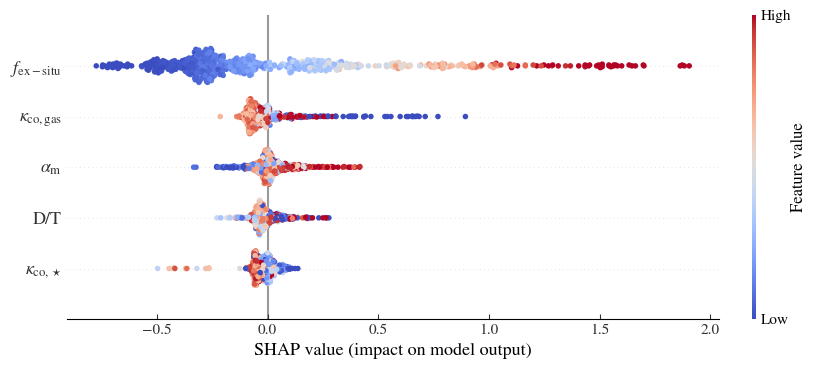

(675, 5, 5)
[[ 8.0495225e-03 -2.1640267e-03  1.3004940e-03 -6.1619766e-03
  -2.0539910e-03]
 [-2.1640251e-03 -1.2861304e-02 -6.9690868e-05 -2.0975873e-02
   6.5124035e-04]
 [ 1.3004942e-03 -6.9696456e-05  1.2015148e-02  2.2366478e-03
  -1.4787301e-02]
 [-6.1619710e-03 -2.0975873e-02  2.2366284e-03  2.4218185e-02
  -3.7036389e-03]
 [-2.0539870e-03  6.5121241e-04 -1.4787315e-02 -3.7036655e-03
  -3.4676725e-01]]
(675, 5)


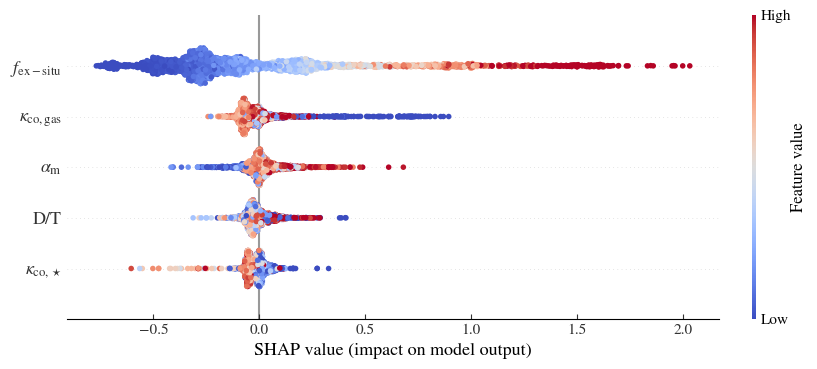

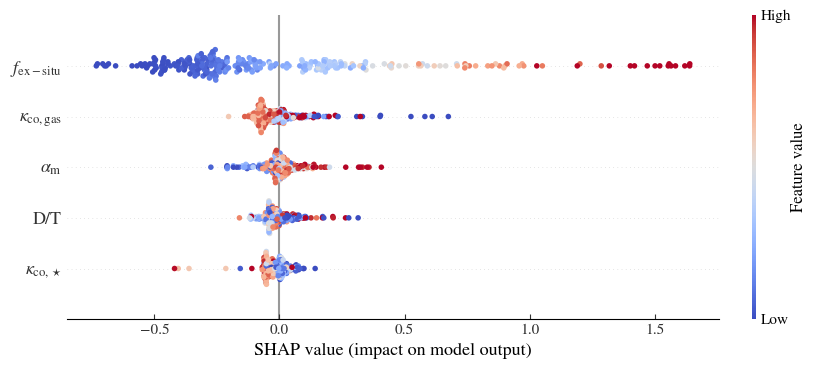

In [72]:
feature_names = ['$\\kappa_{\\rm co,\\star}$', '$\\kappa_{\\rm co,gas}$', '$\\alpha_{\\rm m}$', 'D/T', '$f_{\\rm ex-situ}$']

xgb_model = xgb.XGBRegressor(n_estimators=100, early_stopping_rounds=10)
xgb_model.fit(X_train_scaled, y_train, eval_set=[(X_train_scaled,y_train), (X_val_scaled, y_val)], verbose=10)


yhat = xgb_model.predict(X_train_scaled)

yhat_test = xgb_model.predict(X_test_scaled)
mse = mean_squared_error(y_test, yhat_test)
rmse = mean_squared_error(y_test, yhat_test) ** 0.5
mae = mean_absolute_error(y_test, yhat_test)
r_squared = r2_score(y_test, yhat_test)

print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R^2: {r_squared:.3f}")
print("\n")

explainer = shap.TreeExplainer(xgb_model, 
                               feature_perturbation='tree_path_dependent', 
                               feature_names=feature_names
                               )

shap_values = explainer(X_test_scaled)
shap_interaction = explainer.shap_interaction_values(X_test_scaled)


shap.plots.beeswarm(shap_values, color=plt.get_cmap("coolwarm"))

fig, ax = plt.subplots(1,2, figsize=(14,6), sharex=True, sharey=True, layout='compressed')
ax[0].scatter(y_train, yhat, c='dimgrey', s=10, alpha=0.8)
ax[1].scatter(y_test, yhat_test, c='dimgrey', s=10, alpha=0.8)
ax[0].set_xlabel('Actual')
ax[0].set_ylabel('Predicted')
ax[1].set_xlabel('Actual')
ax[0].set_title('Training set')
ax[1].set_title('Test set')
plt.close()


print(shap_interaction.shape)
print(shap_interaction[0])
print(shap_values.shape)


shap_values = explainer(X_train_scaled)
shap_interaction = explainer.shap_interaction_values(X_train_scaled)
shap.plots.beeswarm(shap_values, color=plt.get_cmap("coolwarm"))

shap_values = explainer(X_val_scaled)
shap_interaction = explainer.shap_interaction_values(X_val_scaled)
shap.plots.beeswarm(shap_values, color=plt.get_cmap("coolwarm"))


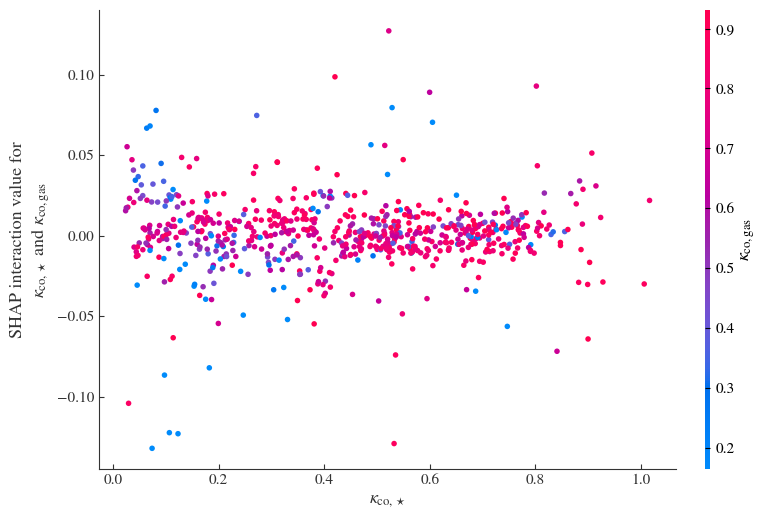

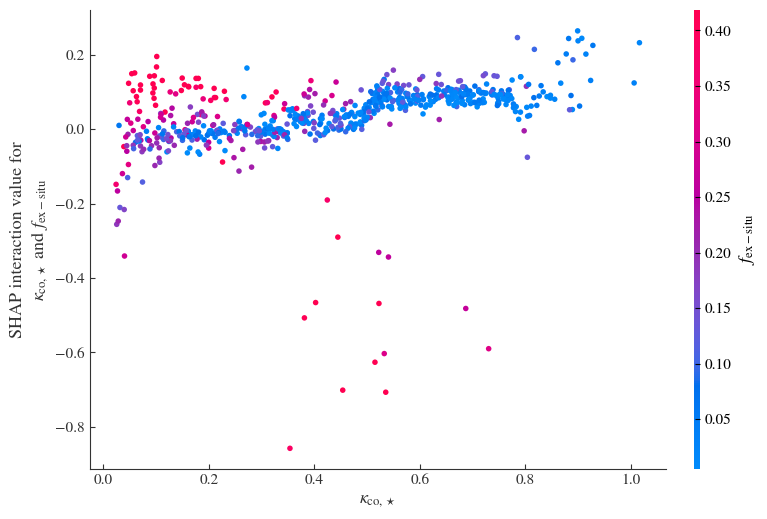

(675, 5, 5)


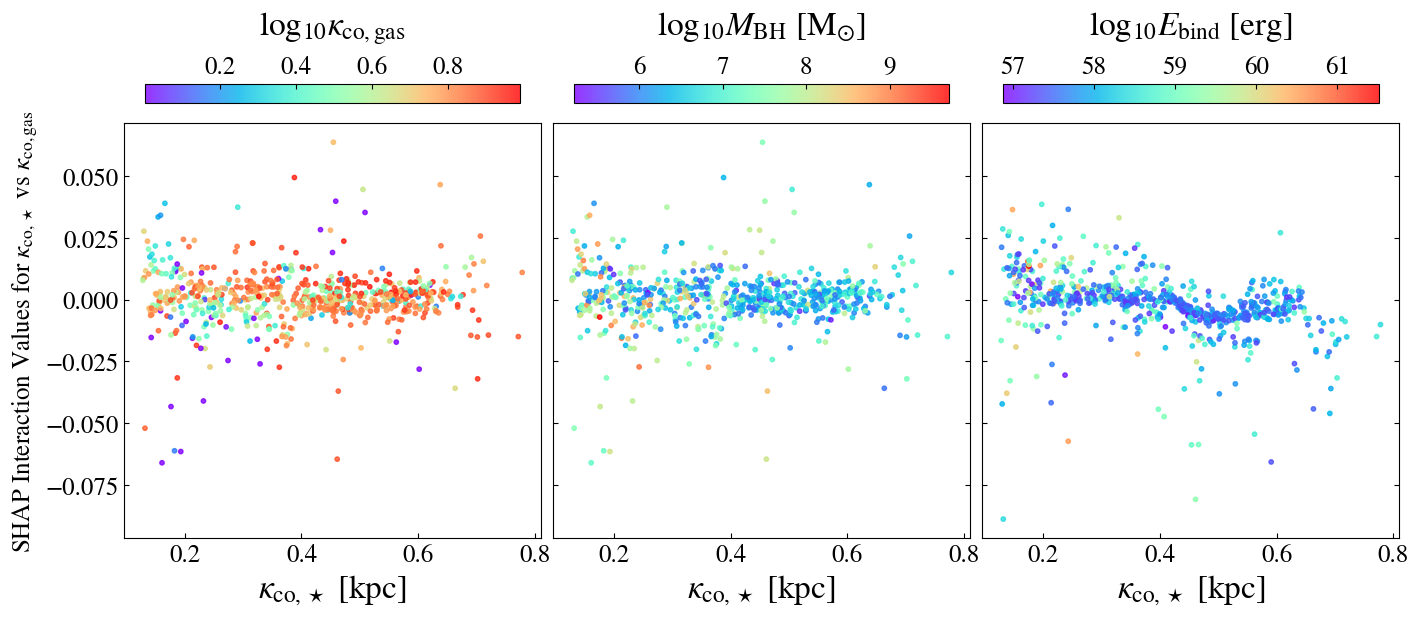

In [74]:
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)
shap_values = explainer(X_test_scaled)
shap_interaction = explainer.shap_interaction_values(X_test_scaled)
shap.dependence_plot(('$\\kappa_{\\rm co,\\star}$', '$\\kappa_{\\rm co,gas}$'), shap_interaction, X_test_df, display_features=X_test_df)
shap.dependence_plot(('$\\kappa_{\\rm co,\\star}$', '$f_{\\rm ex-situ}$'), shap_interaction, X_test_df, display_features=X_test_df)

print(shap_interaction.shape)

ebind_mask = (e_bind[indices_test] >= 58) & (e_bind[indices_test] <= 58.5)

fig, ax = plt.subplots(1,3, figsize=(14,6), sharex=True, sharey=True, layout='compressed')
ax[0].scatter(X_test[:,0], shap_interaction[:,0,1], c=X_test[:,1], s=10, cmap='rainbow', alpha=0.8)
cb = fig.colorbar(ax[0].collections[0], ax=ax[0], location='top', shrink=0.9)
cb.set_label('${\\rm log_{10}}\\kappa_{\\rm co,gas}$', labelpad=15)
ax[0].set_xlabel('$\\kappa_{\\rm co,\\star}$ [kpc]')
ax[0].set_ylabel('SHAP Interaction Values for $\\kappa_{\\rm co,\\star}$ vs $\\kappa_{\\rm co,gas}$', fontsize=18)

ax[1].scatter(X_test[:,0], shap_interaction[:,0,1],  c=m_bh[indices_test], s=10, cmap='rainbow', alpha=0.8)
cb = fig.colorbar(ax[1].collections[0], ax=ax[1], location='top', shrink=0.9)
cb.set_label('${\\rm log_{10}}M_{\\rm BH}$ [$\\rm M_{\\odot}$]', labelpad=15)
ax[1].set_xlabel('$\\kappa_{\\rm co,\\star}$ [kpc]')
ax[1].tick_params(axis='y', labelleft=False, labelright=False, left=True, right=True)

ax[2].scatter(X_test[:,0], shap_interaction[:,0,2],  c=e_bind[indices_test], s=10, cmap='rainbow', alpha=0.8)
cb = fig.colorbar(ax[2].collections[0], ax=ax[2], location='top', shrink=0.9)
cb.set_label('${\\rm log_{10}}E_{\\rm bind}$ [erg]', labelpad=15)
ax[2].set_xlabel('$\\kappa_{\\rm co,\\star}$ [kpc]')
ax[2].tick_params(axis='y', labelleft=False, labelright=False, left=True, right=True)

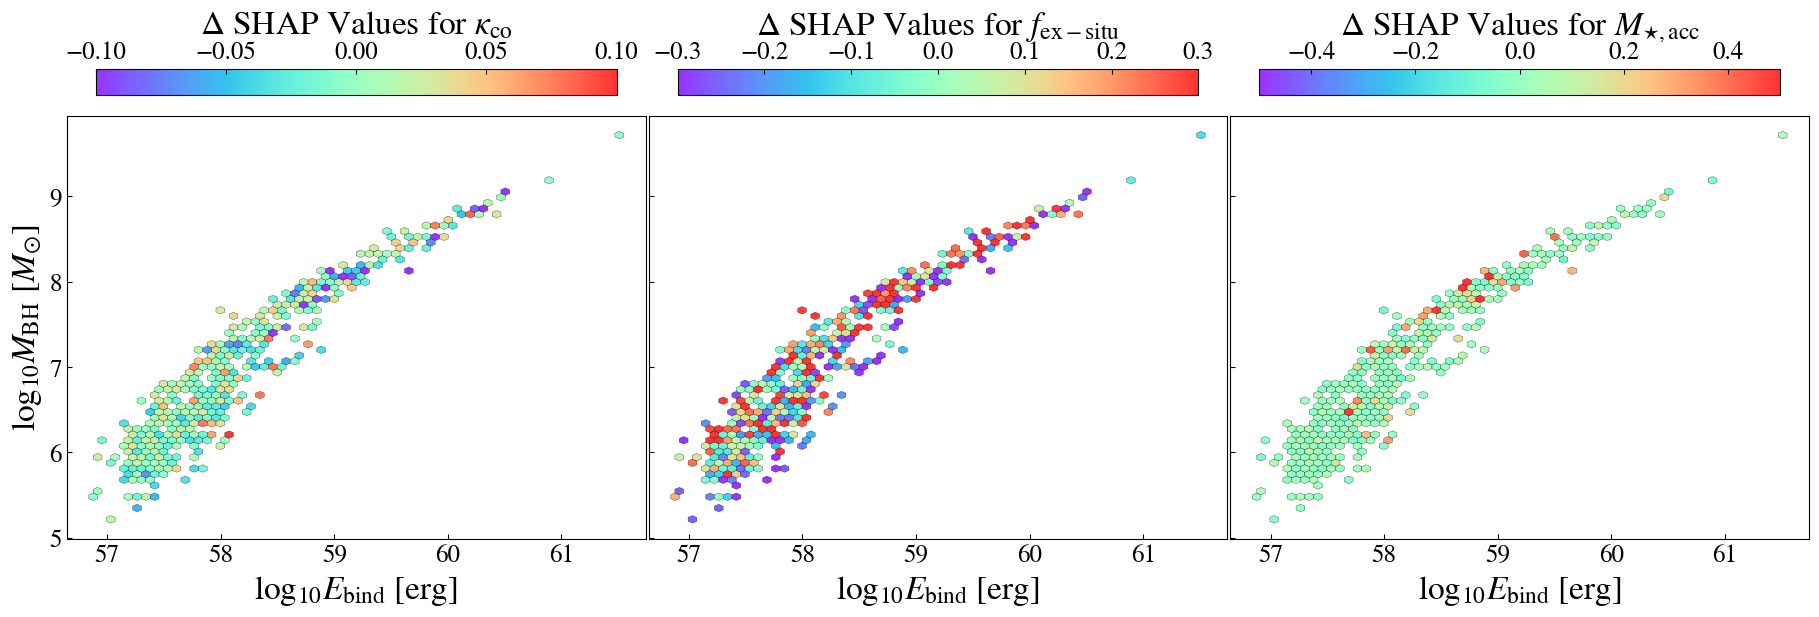

In [76]:
lowess_shap_kappastar = lowess(shap_values.values[:,0], e_bind[indices_test], frac=0.2, it=3, return_sorted=True)[:,1]
delta_shap_kappastar = shap_values.values[:,0][np.argsort(e_bind[indices_test])] - lowess_shap_kappastar

lowess_shap_kappagas = lowess(shap_values.values[:,1], e_bind[indices_test], frac=0.2, it=3, return_sorted=True)[:,1]
delta_shap_kappagas = shap_values.values[:,1][np.argsort(e_bind[indices_test])] - lowess_shap_kappagas

lowess_shap_fexsitu = lowess(shap_values.values[:,4], e_bind[indices_test], frac=0.2, it=3, return_sorted=True)[:,1]
delta_shap_fexsitu = shap_values.values[:,4][np.argsort(e_bind[indices_test])] - lowess_shap_fexsitu

fig, ax = plt.subplots(1,3, figsize=(18,6), sharex=True, sharey=True, layout='compressed')
ax[0].hexbin(e_bind[indices_test][np.argsort(e_bind[indices_test])], y_test[np.argsort(e_bind[indices_test])], 
              C=delta_shap_kappastar, reduce_C_function=np.mean, gridsize=60, 
              edgecolors='k', linewidth=0.25, cmap='rainbow', alpha=0.8,
              vmin=-0.1, vmax=0.1)
cb = fig.colorbar(ax[0].collections[0], ax=ax[0], location='top', shrink=0.9)
cb.set_label('$\\Delta$ SHAP Values for $\\kappa_{\\rm co}$')
ax[0].set_xlabel('${\\rm log_{10}}E_{\\rm bind}$ [erg]')
ax[0].set_ylabel('${\\rm log_{10}}M_{\\rm BH}$ [$M_{\\odot}$]')

ax[1].hexbin(e_bind[indices_test][np.argsort(e_bind[indices_test])], y_test[np.argsort(e_bind[indices_test])], 
              C=delta_shap_fexsitu, reduce_C_function=np.mean, gridsize=60, 
              edgecolors='k', linewidth=0.25, cmap='rainbow', alpha=0.8,
              vmin=-0.3, vmax=0.3)
cb = fig.colorbar(ax[1].collections[0], ax=ax[1], location='top', shrink=0.9)
cb.set_label('$\\Delta$ SHAP Values for $f_{\\rm ex-situ}$')
ax[1].set_xlabel('${\\rm log_{10}}E_{\\rm bind}$ [erg]')

ax[2].hexbin(e_bind[indices_test][np.argsort(e_bind[indices_test])], y_test[np.argsort(e_bind[indices_test])], 
              C=delta_shap_kappagas, reduce_C_function=np.mean, gridsize=60, 
              edgecolors='k', linewidth=0.25, cmap='rainbow', alpha=0.8,
              vmin=-0.5, vmax=0.5)
cb = fig.colorbar(ax[2].collections[0], ax=ax[2], location='top', shrink=0.9)
cb.set_label('$\\Delta$ SHAP Values for $M_{\\star,\\rm acc}$')
ax[2].set_xlabel('${\\rm log_{10}}E_{\\rm bind}$ [erg]')

plt.show()

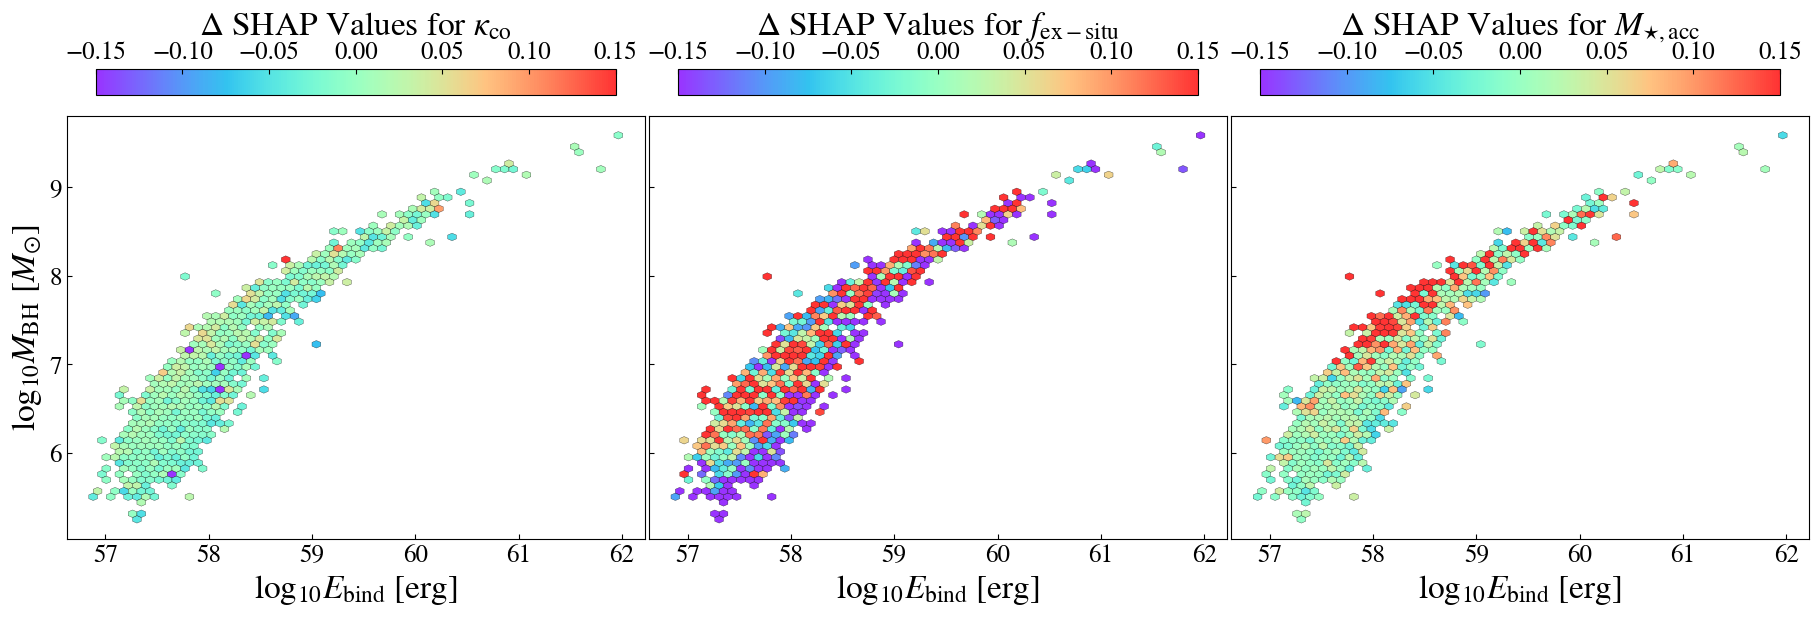

In [78]:
shap_values = explainer(X_train_scaled)
shap_interaction = explainer.shap_interaction_values(X_train_scaled)

lowess_shap_kappastar = lowess(shap_values.values[:,0], e_bind[indices_train], frac=0.2, it=3, return_sorted=True)[:,1]
delta_shap_kappastar = shap_values.values[:,0][np.argsort(e_bind[indices_train])] - lowess_shap_kappastar

lowess_shap_kappagas = lowess(shap_values.values[:,1], e_bind[indices_train], frac=0.2, it=3, return_sorted=True)[:,1]
delta_shap_kappagas = shap_values.values[:,1][np.argsort(e_bind[indices_train])] - lowess_shap_kappagas

lowess_shap_fexsitu = lowess(shap_values.values[:,4], e_bind[indices_train], frac=0.2, it=3, return_sorted=True)[:,1]
delta_shap_fexsitu = shap_values.values[:,4][np.argsort(e_bind[indices_train])] - lowess_shap_fexsitu

fig, ax = plt.subplots(1,3, figsize=(18,6), sharex=True, sharey=True, layout='compressed')
ax[0].hexbin(e_bind[indices_train][np.argsort(e_bind[indices_train])], y_train[np.argsort(e_bind[indices_train])], 
              C=delta_shap_kappastar, reduce_C_function=np.mean, gridsize=60, 
              edgecolors='k', linewidth=0.25, cmap='rainbow', alpha=0.8,
              vmin=-0.15, vmax=0.15)
cb = fig.colorbar(ax[0].collections[0], ax=ax[0], location='top', shrink=0.9)
cb.set_label('$\\Delta$ SHAP Values for $\\kappa_{\\rm co}$')
ax[0].set_xlabel('${\\rm log_{10}}E_{\\rm bind}$ [erg]')
ax[0].set_ylabel('${\\rm log_{10}}M_{\\rm BH}$ [$M_{\\odot}$]')

ax[1].hexbin(e_bind[indices_train][np.argsort(e_bind[indices_train])], y_train[np.argsort(e_bind[indices_train])], 
              C=delta_shap_fexsitu, reduce_C_function=np.mean, gridsize=60, 
              edgecolors='k', linewidth=0.25, cmap='rainbow', alpha=0.8,
              vmin=-0.15, vmax=0.15)
cb = fig.colorbar(ax[1].collections[0], ax=ax[1], location='top', shrink=0.9)
cb.set_label('$\\Delta$ SHAP Values for $f_{\\rm ex-situ}$')
ax[1].set_xlabel('${\\rm log_{10}}E_{\\rm bind}$ [erg]')

ax[2].hexbin(e_bind[indices_train][np.argsort(e_bind[indices_train])], y_train[np.argsort(e_bind[indices_train])], 
              C=delta_shap_kappagas, reduce_C_function=np.mean, gridsize=60, 
              edgecolors='k', linewidth=0.25, cmap='rainbow', alpha=0.8,
              vmin=-0.15, vmax=0.15)
cb = fig.colorbar(ax[2].collections[0], ax=ax[2], location='top', shrink=0.9)
cb.set_label('$\\Delta$ SHAP Values for $M_{\\star,\\rm acc}$')
ax[2].set_xlabel('${\\rm log_{10}}E_{\\rm bind}$ [erg]')

plt.show()